In [1]:
import tensorflow as tf
from tensorflow import keras

from nn.alice import dataset, model
from physics.hstar import gghzz, c6
from physics.simulation import msq
from physics.hzz import zpair, kinematics

import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import hist

from sklearn.preprocessing import MinMaxScaler

2025-01-21 14:08:42.043630: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-21 14:08:48.495517: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-21 14:08:48.495608: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-21 14:08:48.495830: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-21 14:08:50.462690: I tensorflow/core/platform/cpu_feature_g

In [2]:
SEED=373485

BASE_SIZE=1000

OUTPUT_DIR='jobs/alice/run-ten-bs32-1e-5'
CONF_FILE='alice-config.json'
SCALER_CONF='scaler.json'
SAMPLE_DIR='..'

COMPONENT_1 = msq.Component.SIG
COMPONENT_2 = msq.Component.BKG

In [3]:
with open(os.path.join(OUTPUT_DIR, CONF_FILE), 'r') as conf_file:
    config = json.load(conf_file)

In [4]:
sample = gghzz.Process(COMPONENT_2, (1.6, os.path.join(SAMPLE_DIR, 'ggZZ2e2m_bkg.csv'), BASE_SIZE*1.2))

bkg_null_filter = msq.MSQFilter('msq_bkg_sm', value=0.0)
bkg_nan_filter = msq.MSQFilter('msq_bkg_sm', value=np.nan)

z_candidate = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZMasses(bounds1 = (70,115), bounds2 = (70,115))

angles = kinematics.AngularVariables()
four_lepton = kinematics.FourLeptonSystem()

events_training, events_validation = sample.events.filter(bkg_null_filter).filter(bkg_nan_filter).calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton)[:int(config['num_events'])][:BASE_SIZE].split(training=0.5, validation=0.5)
sig_prob_training, sig_prob_validation = [evt.probabilities for evt in sample[COMPONENT_1].filter(bkg_null_filter).filter(bkg_nan_filter).calculate(z_candidate).filter(z_masses).calculate(angles).calculate(four_lepton)[:int(config['num_events'])].shuffle(random_state=SEED)[:BASE_SIZE].split(training=0.5, validation=0.5)]

In [5]:
kin_variables = ['cth_star', 'cth_1', 'cth_2', 'phi_1', 'phi', 'Z1_mass', 'Z2_mass', '4l_mass', '4l_rapidity']

kinematics_training = events_training.kinematics[kin_variables].to_numpy()
kinematics_validation = events_validation.kinematics[kin_variables].to_numpy()

train_data = dataset.build_dataset(x_arr = kinematics_training,
                                   signal_probabilities = sig_prob_training,
                                   background_probabilities = events_training.probabilities)
    
val_data = dataset.build_dataset(x_arr = kinematics_validation,
                                 signal_probabilities = sig_prob_validation,
                                 background_probabilities = events_validation.probabilities)

2025-01-21 14:09:45.804075: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [25]:
with open(os.path.join(OUTPUT_DIR, SCALER_CONF), 'r') as conf_file:
    scaler_conf = json.load(conf_file)

In [26]:
scaler = MinMaxScaler()
scaler.min_ = scaler_conf['scaler.min_']
scaler.scale_ = scaler_conf['scaler.scale_']

train_set = tf.concat([scaler.transform(train_data[:,:-2]), train_data[:,-2:]], axis=1)
val_set = tf.concat([scaler.transform(val_data[:,:-2]), val_data[:,-2:]], axis=1)

In [28]:
alice_model = model.load(os.path.join(OUTPUT_DIR, 'checkpoint.model.tf'))

In [29]:
predictions_train = alice_model.predict(train_set[:,:-2])
predictions_val = alice_model.predict(val_set[:,:-2])

16/16 [==============================] - 5s 333ms/step


In [35]:
def generate_histograms(data_train, pred_train, data_val, pred_val, num_bins):
    histograms = []

    hist_train = hist.Hist(hist.axis.Regular(num_bins, 0, 2, name='x', label='NN predicted ratio []'))
    hist_train.fill(tf.squeeze(pred_train/(1-pred_train), axis=1), weight=data_train[:,-1])

    hist_val = hist.Hist(hist.axis.Regular(num_bins, 0, 2, name='x', label='NN predicted ratio []'))
    hist_val.fill(tf.squeeze(pred_val/(1 - pred_val), axis=1), weight=data_val[:,-1])

    hist_true = hist.Hist(hist.axis.Regular(num_bins, 0, 2, name='x', label='NN predicted ratio []'))
    hist_true.fill(data_train[:,-2]/(1 - data_train[:,-2]), weight=data_train[:,-1])

    hist_val_true = hist.Hist(hist.axis.Regular(num_bins, 0, 2, name='x', label='NN predicted ratio []'))
    hist_val_true.fill(data_val[:,-2]/(1-data_val[:,-2]), weight=data_val[:,-1])

    histograms.append((hist_train.to_numpy(), hist_val.to_numpy(), hist_true.to_numpy(), hist_val_true.to_numpy()))
    
    return histograms

In [36]:
def plot_histograms(c6_values, histograms, colors, xlim=(0.2,0.8)):
    fig = plt.figure(figsize=(7,6))

    for i in range(len(c6_values)):
        plt.step(histograms[i][2][1][1:], histograms[i][2][0], color=colors[i], linestyle='--', label=f'truth (training) (c6={c6_values[i]})', alpha=0.6)
        plt.step(histograms[i][3][1][1:], histograms[i][3][0], color=colors[i+1], linestyle='--', label=f'truth (validation) (c6={c6_values[i]})', alpha=0.6)
        plt.step(histograms[i][0][1][1:], histograms[i][0][0], color=colors[i], label=f'training data (c6={c6_values[i]})', alpha=0.6)
        plt.scatter(histograms[i][1][1][1:], histograms[i][1][0], s=20, color=colors[i+1], label=f'validation data (c6={c6_values[i]})', alpha=0.6)

    plt.xlabel('NN output []')
    plt.ylabel('Percentage of predictions []')
    plt.legend()
    plt.xlim(xlim[0],xlim[1])
    plt.yscale('log')

    plt.show()

(500,)
(500, 1)


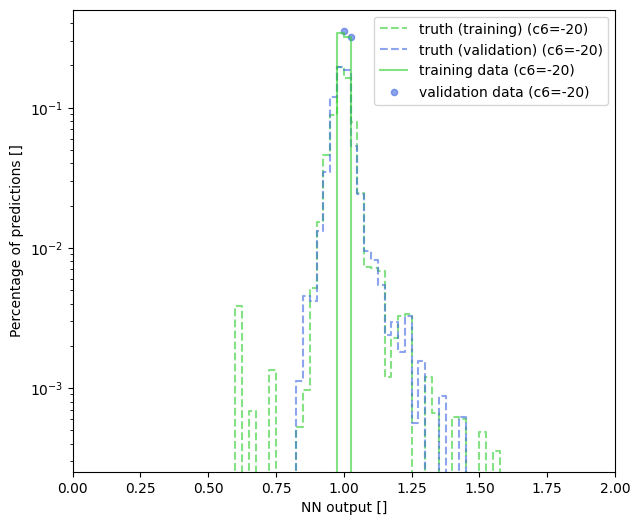

In [38]:
BINS = 80

c6_vals = [-20]
colors = ['limegreen', 'royalblue', 'limegreen', 'royalblue']

print(train_data[:,-2].shape)
print(predictions_train.shape)

histograms = generate_histograms(train_data, predictions_train, val_data, predictions_val, BINS)

plot_histograms(c6_vals, histograms, colors, xlim=(0,2.0))

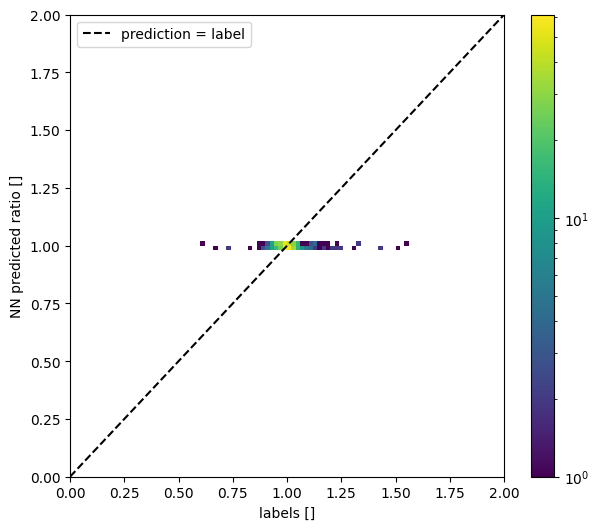

In [39]:
bounds = [0.0,2.0]

c6_val=-10

fig, ax = plt.subplots(figsize=(7,6))

im = ax.hist2d(train_data[:,-2]/(1-train_data[:,-2]), predictions_train.T[0]/(1-predictions_train.T[0]), bins=100, range=[bounds,bounds], norm=LogNorm(), cmin=0.0)
ax.plot(np.linspace(*bounds), np.linspace(*bounds), '--', color='k', label='prediction = label')

fig.colorbar(im[3], ax=ax)

plt.xlabel(f'labels []')
plt.ylabel(f'NN predicted ratio []')
plt.legend()

plt.show()

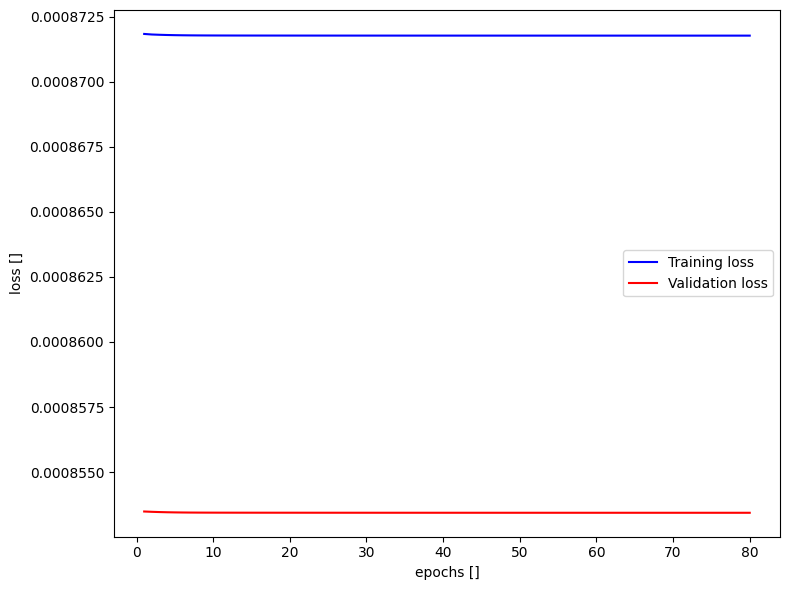

In [40]:
hist_prm = ''

with open(os.path.join(OUTPUT_DIR, 'history.txt'), 'r') as hist_file:
    hist_prm = hist_file.readlines()

hist_prm = [ np.array(el.replace('[','').replace(']','').replace(' ','').split(','), dtype=float) for el in hist_prm[0].split('][')]

t_loss_prm = np.array(hist_prm[0])
v_loss_prm = np.array(hist_prm[1])

epochs = range(1,t_loss_prm.shape[0]+1)

fig = plt.figure(figsize=(8,6))

#ax1.set_xticklabels([])

plt.plot(epochs, t_loss_prm, 'b', label='Training loss')
plt.xlabel('epochs []')
plt.ylabel(f'loss []')
#ax2.legend()

plt.plot(epochs, v_loss_prm, 'r', label='Validation loss')
#ax1.set_ylabel('loss []')
plt.legend()

fig.tight_layout()

plt.show()

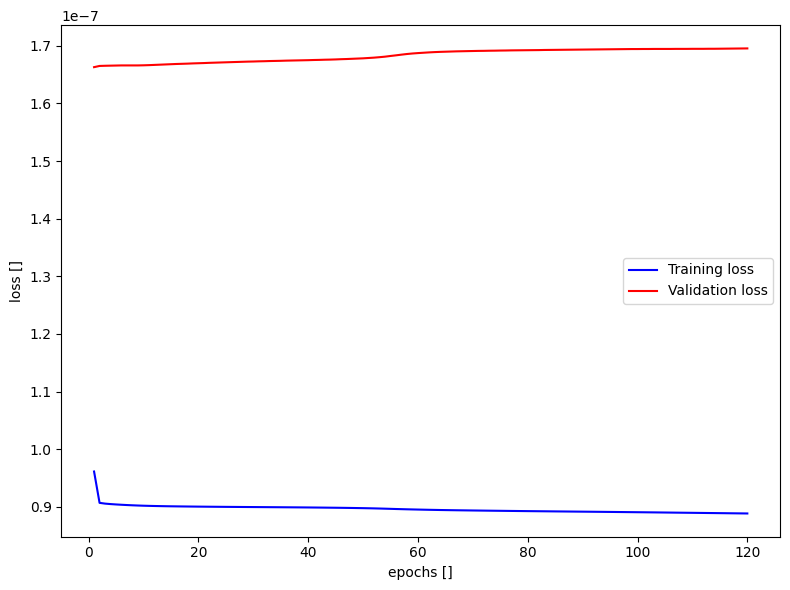

In [ ]:
JOB_ID = 14725450

JOB_OUT_FILE = os.path.join(OUTPUT_DIR, 'logs', 'job.out.' + str(JOB_ID))

import re

with open(JOB_OUT_FILE, 'r') as log_file:
    logs = ''.join(log_file.readlines())

t_loss = np.array(re.findall("\ loss:\ ([0-9]\.[0-9]+e?-?[0-9]*)\ -", logs)).astype(np.float32)
v_loss = np.array(re.findall("\ val_loss:\ ([0-9]\.[0-9]+e?-?[0-9]*)\ -", logs)).astype(np.float32)

epochs = range(1,t_loss.shape[0]+1)

fig = plt.figure(figsize=(8,6))

#ax1.set_xticklabels([])

plt.plot(epochs, t_loss, 'b', label='Training loss')
plt.xlabel('epochs []')
plt.ylabel(f'loss []')
#ax2.legend()

plt.plot(epochs, v_loss, 'r', label='Validation loss')
#ax1.set_ylabel('loss []')
plt.legend()

fig.tight_layout()

plt.show()